**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC5053 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 8**
Regresión Lineal

---

*   NOMBRE: ---------------------------------------------------------
*   MATRÍCULA: ----------------------------------------------------

En esta actividad trabajarás con el archivo `diamonds_dataset.csv`, basado en un conjunto de datos sobre características de diamantes, disponible en el paquete ggplot2 de R y en repositorios públicos de análisis de datos.

Los datos fueron recopilados para analizar el precio de los diamantes en función de sus propiedades físicas y cualidades de corte, color y claridad. Los indicadores incluidos son:

* `carat`: Peso del diamante en quilates
* `cut`: Calidad del corte del diamante (Fair, Good, Very Good, Premium, Ideal)
* `color`: Color del diamante, de D (mejor) a J (peor)
* `clarity`: Claridad del diamante (I1, SI2, SI1, VS2, VS1, VVS2, VVS1, IF)
* `depth`: Profundidad total del diamante como porcentaje: z / mean(x, y)
* `table`: Ancho de la tabla del diamante como porcentaje de x
* `x`: Longitud en mm
* `y`: Ancho en mm
* `z`: Profundidad en mm
* `price`: Precio del diamante en dólares estadounidenses. Es la variable de salida o *target*

**NOTA IMPORTANTE:** Asegúrate de responder *explícitamente* todos los cuestionamientos.

In [709]:
# Importar las bibliotecas necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, RobustScaler
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error

1. Descarga el archivo: `diamonds_dataset.csv` y guarda, en un dataframe (`diamonds_df`), todos sus registros.
* Utiliza el método `info()` del dataframe, para obtener el resumen de los tipos de datos. ¿Cuántas columnas son numéricas y cuántas de texto?
* Determina la cantidad de valores únicos por columna.
* Verifica si alguna columna contiene valores faltantes.
* Si existen registros duplicados, elimínalos del dataframe y reinicia el índice para que se mantenga consecutivo.

In [710]:
diamonds_df = pd.read_csv("/Users/chicano/Documents/Tec/1-Trimestre/Ciencia y Analisis de datos/Semana 8 (Oct 27 - Nov 2)/Actividad 8 - Regression Lineal/diamonds_dataset.csv")
diamonds_df.info()
# Columnas = 10 total
# 7 Numéricas
# 3 Texto

# Calcular la cantidad de valores únicos para cada columna
unique_counts = diamonds_df.nunique().reset_index()

# Renombrar las columnas para mayor claridad
unique_counts.columns = ['Columna', 'Cantidad de Valores Únicos']

# Mostrar el resultado
print("--------" * 5)
print(unique_counts.to_markdown(index=False, numalign='left', stralign='left'))



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53936 entries, 0 to 53935
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53936 non-null  float64
 1   cut      53936 non-null  object 
 2   color    53936 non-null  object 
 3   clarity  53936 non-null  object 
 4   depth    53936 non-null  float64
 5   table    53936 non-null  float64
 6   x        53936 non-null  float64
 7   y        53936 non-null  float64
 8   z        53936 non-null  float64
 9   price    53936 non-null  int64  
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB
----------------------------------------
| Columna   | Cantidad de Valores Únicos   |
|:----------|:-----------------------------|
| carat     | 271                          |
| cut       | 5                            |
| color     | 7                            |
| clarity   | 8                            |
| depth     | 184                          |
| table     | 127

In [711]:
# Verifica si alguna columna contiene valores faltantes.

# La función isna().sum() cuenta el número de valores nulos (NaN) por columna.
valores_faltantes = diamonds_df.isna().sum().reset_index()
valores_faltantes.columns = ['Columna', 'Valores Faltantes']

valores_faltantes_total = valores_faltantes[valores_faltantes['Valores Faltantes'] > 0]

# Imprimir el resultado
if valores_faltantes_total.empty:
    print("No se encontraron valores faltantes en ninguna de las columnas del dataset.")
else:
    print("Columnas con valores faltantes:")
    print(valores_faltantes_total.to_markdown(index=False, numalign='left', stralign='left'))

diamonds_df

No se encontraron valores faltantes en ninguna de las columnas del dataset.


,carat,cut,color,clarity,depth,table,x,y,z,price
0,0.23,Ideal,E,SI2,61.5,55.0,3.95,3.98,2.43,326
1,0.21,Premium,E,SI1,59.8,61.0,3.89,3.84,2.31,326
2,0.23,Good,E,VS1,56.9,65.0,4.05,4.07,2.31,327
3,0.29,Premium,I,VS2,62.4,58.0,4.20,4.23,2.63,334
4,0.31,Good,J,SI2,63.3,58.0,4.34,4.35,2.75,335
...,...,...,...,...,...,...,...,...,...,...
53931,0.72,Ideal,D,SI1,60.8,57.0,5.75,5.76,3.50,2757
53932,0.72,Good,D,SI1,63.1,55.0,5.69,5.75,3.61,2757
53933,0.70,Very Good,D,SI1,62.8,60.0,5.66,5.68,3.56,2757
53934,0.86,Premium,H,SI2,61.0,58.0,6.15,6.12,3.74,2757


In [712]:
# Si existen registros duplicados, elimínalos del dataframe y reinicia el índice para que se mantenga consecutivo.
# Calcular el número de filas duplicadas antes de la eliminación
conteo_filas_duplicadas = diamonds_df.duplicated().sum()

print(f"Número de filas duplicadas encontradas: {conteo_filas_duplicadas}")

# Eliminar filas duplicadas (conservando la primera ocurrencia por defecto)
diamonds_df_limpio = diamonds_df.drop_duplicates()

# 3. Reiniciar el índice para que sea consecutivo, usando 'drop=True' para no convertir el índice antiguo en una columna.
diamonds_df_limpio = diamonds_df_limpio.reset_index(drop=True)

# 4. Reemplazar el DataFrame original con el limpio
diamonds_df_nuevo = diamonds_df_limpio

# 5. Mostrar la nueva forma del DataFrame y las primeras filas (solo para verificación)
print(f"Nueva forma del DataFrame después de eliminar duplicados: {diamonds_df_nuevo.shape}")
print("Primeras 5 filas del DataFrame con el índice reiniciado:")
print(diamonds_df_nuevo.head())

Número de filas duplicadas encontradas: 146
Nueva forma del DataFrame después de eliminar duplicados: (53790, 10)
Primeras 5 filas del DataFrame con el índice reiniciado:
   carat      cut color clarity  depth  table     x     y     z  price
0   0.23    Ideal     E     SI2   61.5   55.0  3.95  3.98  2.43    326
1   0.21  Premium     E     SI1   59.8   61.0  3.89  3.84  2.31    326
2   0.23     Good     E     VS1   56.9   65.0  4.05  4.07  2.31    327
3   0.29  Premium     I     VS2   62.4   58.0  4.20  4.23  2.63    334
4   0.31     Good     J     SI2   63.3   58.0  4.34  4.35  2.75    335


2. Obtén las estadísticas descriptivas, separando las variables numéricas y las categóricas. De estas últimas incluye las tablas de frecuencia.
* Para las variables numéricas genera histogramas y boxplots para explorar la distribución y la dispersión.
* Para las variables categóricas utiliza diagramas de barras para visualizar la frecuencia de cada categoría.

In [713]:
# Código de la etapa 1 (Estadísticas Descriptivas)
columnas_numericas = diamonds_df_nuevo.select_dtypes(include=['float64', 'int64']).columns
columnas_categoricas = diamonds_df_nuevo.select_dtypes(include=['object']).columns
estadistica_numerica = diamonds_df_nuevo[columnas_numericas].describe().T

print("----- Estadísticas Descriptivas para Variables Numéricas -----")
print(estadistica_numerica.to_markdown(numalign='left', stralign='left'))

# --- Tablas de Frecuencia ---
print("\n----- Tablas de Frecuencia para Variables Categóricas -----")
for col in columnas_categoricas:
    freq_df = diamonds_df_nuevo[col].value_counts().reset_index()
    freq_df.columns = [col, 'Frecuencia']
    print(f"\nTabla de Frecuencia para la columna: '{col}'")
    print(freq_df.to_markdown(index=False, numalign='left', stralign='left'))


----- Estadísticas Descriptivas para Variables Numéricas -----
|       | count   | mean     | std      | min   | 25%   | 50%   | 75%     | max   |
|:------|:--------|:---------|:---------|:------|:------|:------|:--------|:------|
| carat | 53790   | 0.797567 | 0.472696 | 0.2   | 0.4   | 0.7   | 1.04    | 4.5   |
| depth | 53790   | 61.748   | 1.42979  | 43    | 61    | 61.8  | 62.5    | 79    |
| table | 53790   | 57.4579  | 2.23361  | 43    | 56    | 57    | 59      | 95    |
| x     | 53790   | 5.73092  | 1.12019  | 0     | 4.71  | 5.7   | 6.54    | 10.23 |
| y     | 53790   | 5.73436  | 1.14074  | 0     | 4.72  | 5.71  | 6.54    | 58.9  |
| z     | 53790   | 3.53852  | 0.704699 | 0     | 2.91  | 3.53  | 4.03    | 31.8  |
| price | 53790   | 3932.17  | 3986.88  | 326   | 951   | 2401  | 5324.75 | 18823 |

----- Tablas de Frecuencia para Variables Categóricas -----

Tabla de Frecuencia para la columna: 'cut'
| cut       | Frecuencia   |
|:----------|:-------------|
| Ideal     | 2148

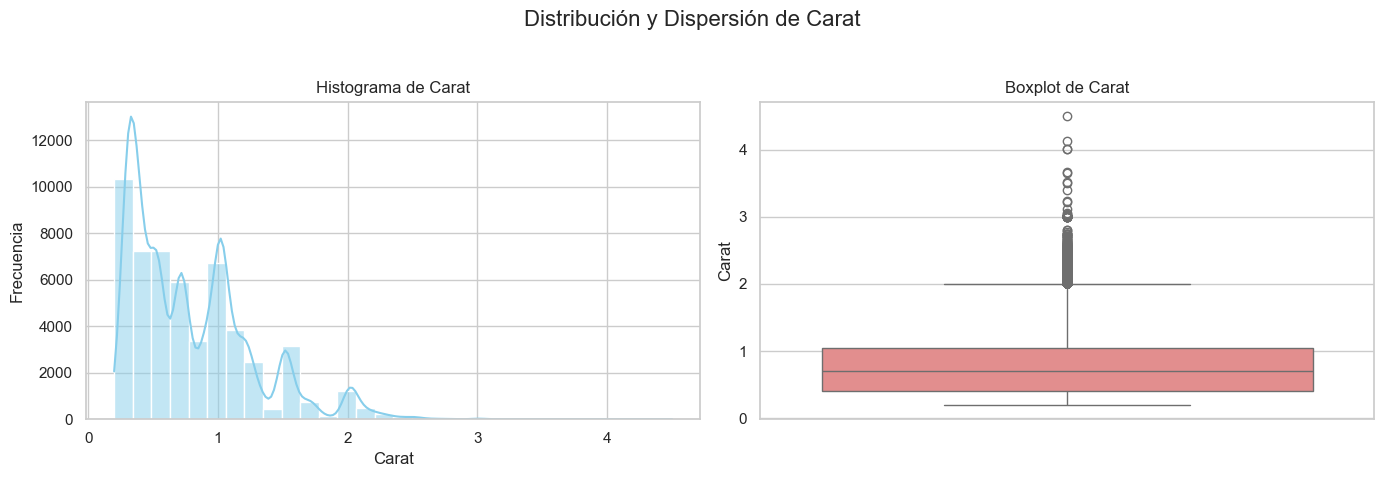

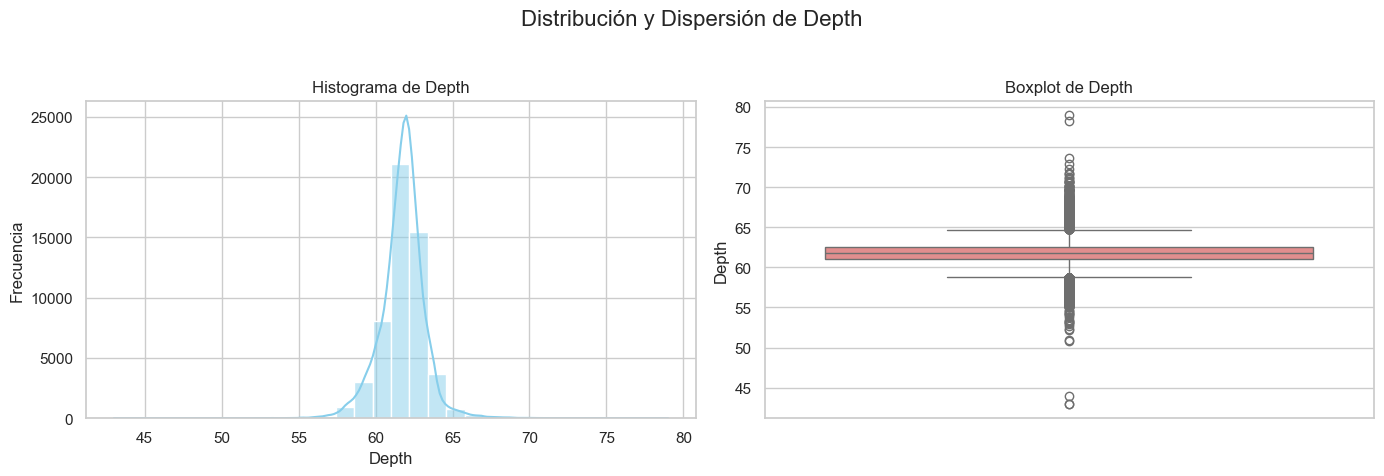

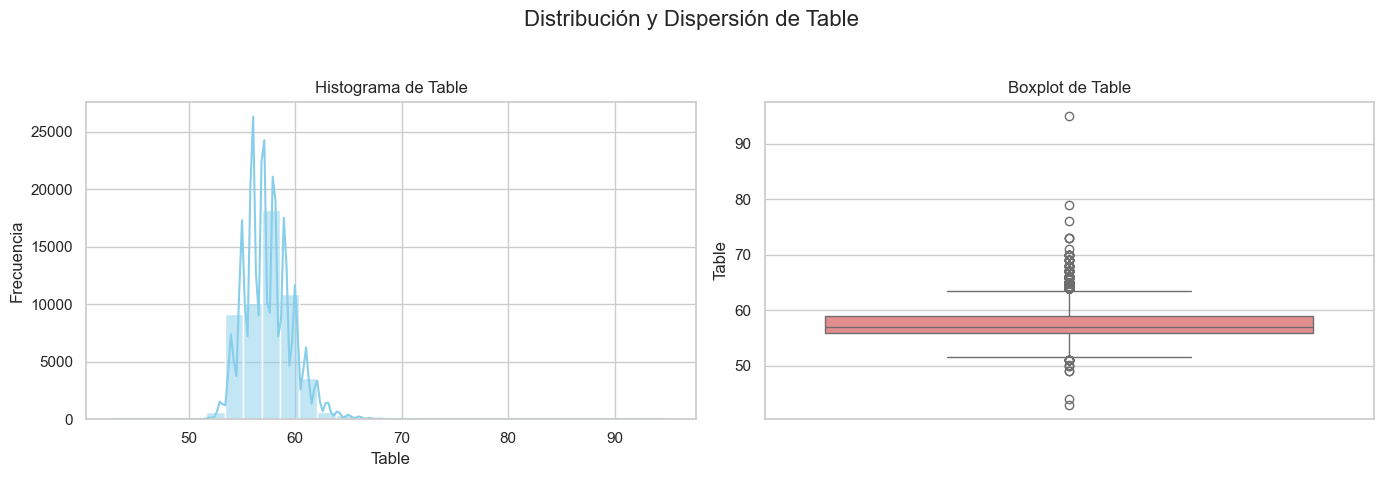

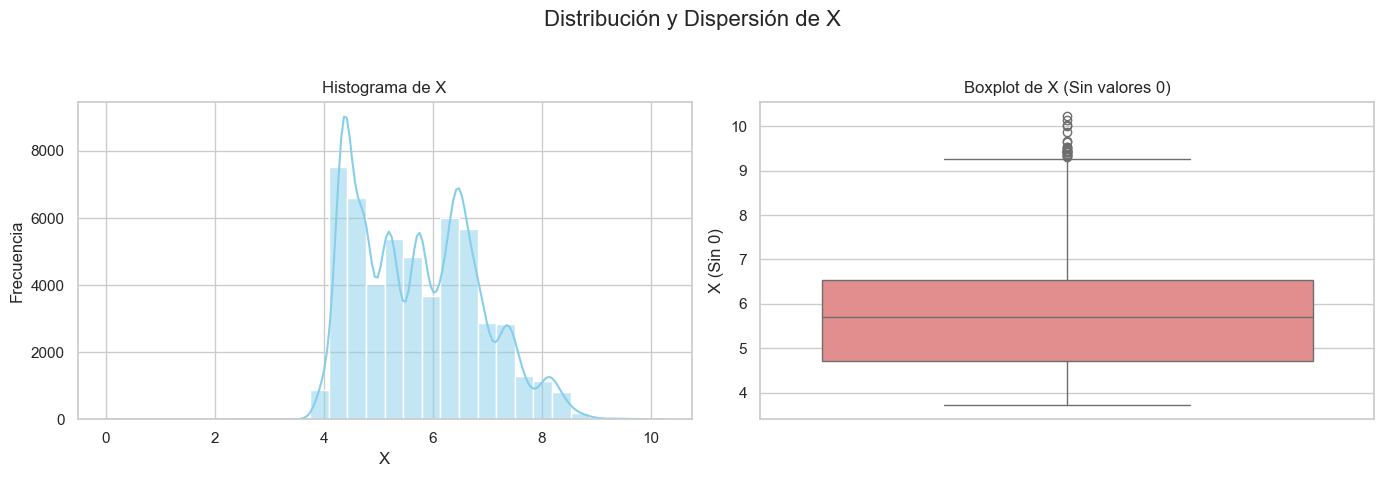

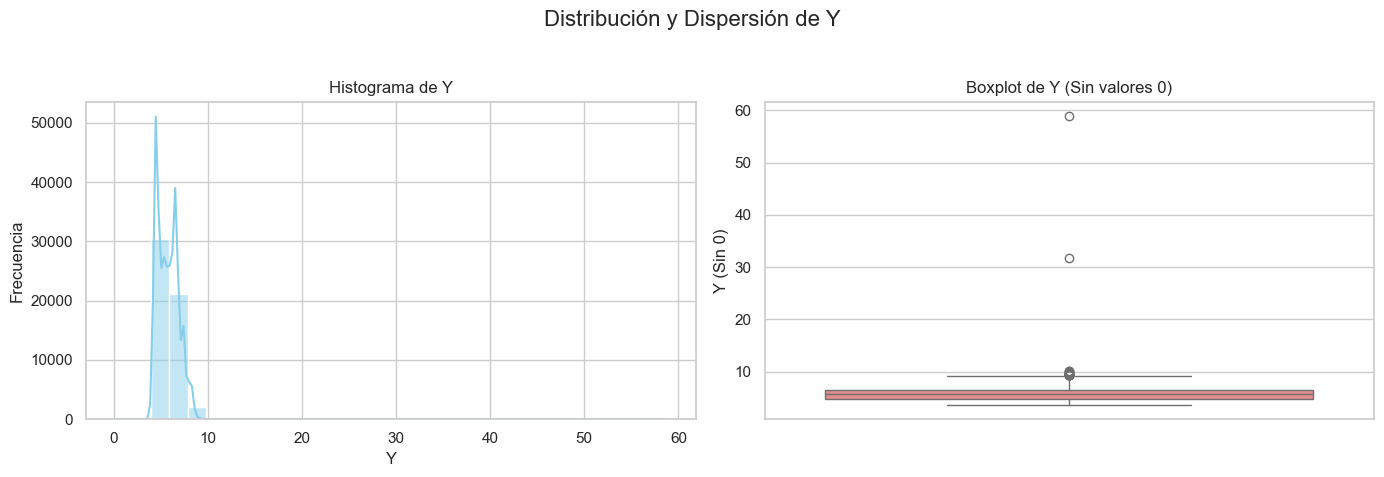

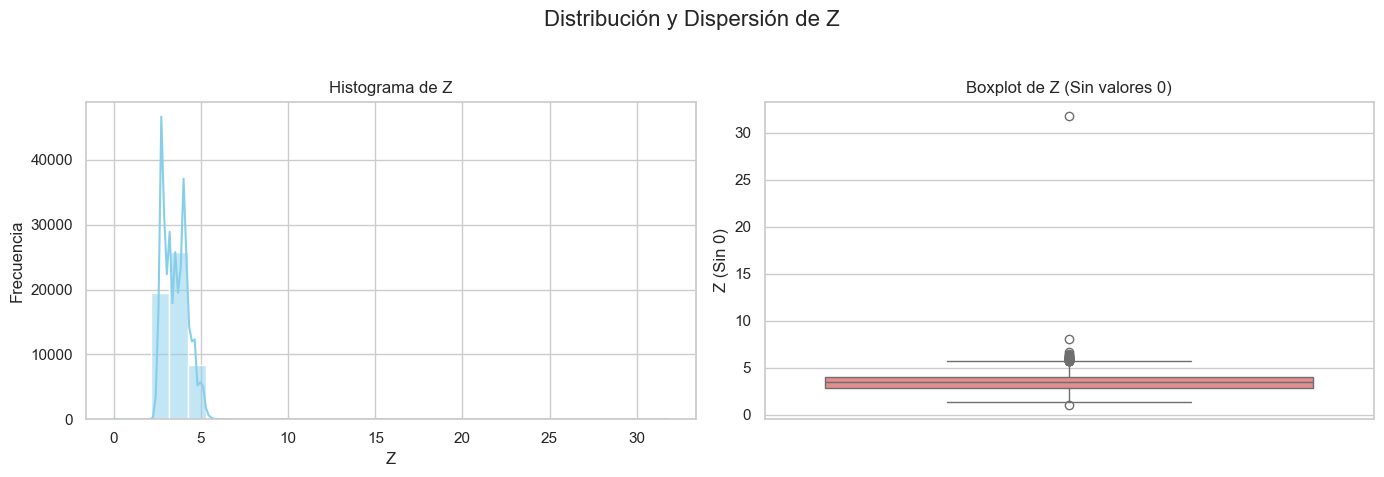

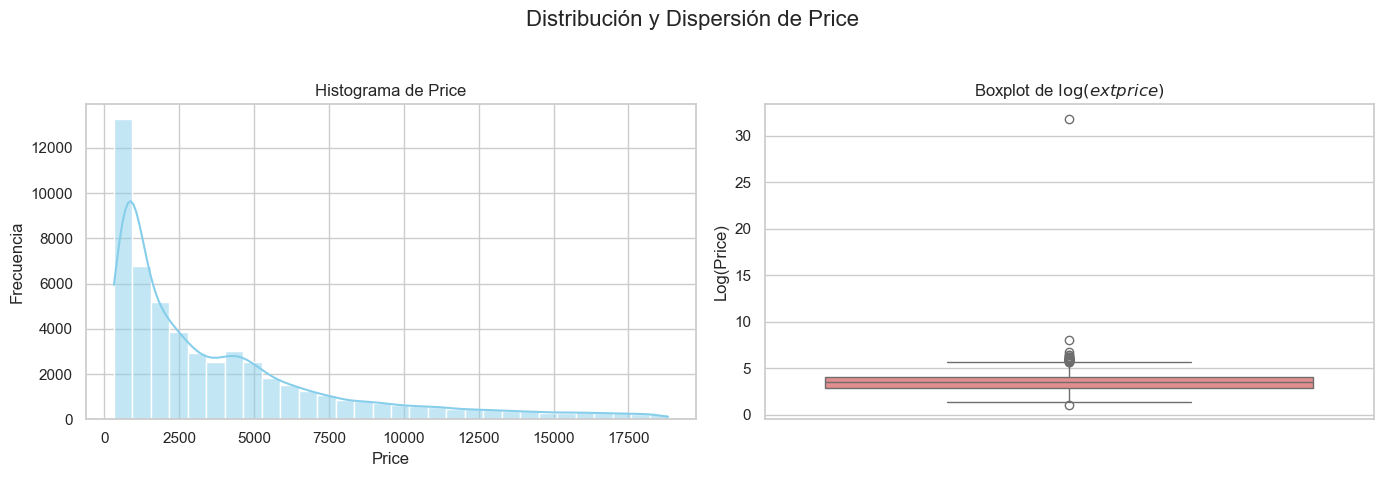

In [714]:
# Para las variables numéricas genera histogramas y boxplots para explorar la distribución y la dispersión.
# --- Generación de Gráficos ---

# Configuración de estilo
sns.set_style("whitegrid")

# Histogramas y Boxplots para Numéricas
for col in columnas_numericas:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Distribución y Dispersión de {col.capitalize()}', fontsize=16)

    # Subplot 1: Histograma
    sns.histplot(diamonds_df_nuevo[col], kde=True, ax=axes[0], bins=30, color='skyblue')
    axes[0].set_title(f'Histograma de {col.capitalize()}')
    axes[0].set_xlabel(col.capitalize())
    axes[0].set_ylabel('Frecuencia')

    # Subplot 2: Boxplot (Manejo de valores 0 y log-transformación para Price)
    if col in ['x', 'y', 'z']:
        # Excluir valores 0 para mejorar la visualización del boxplot (datos anómalos)
        data_to_plot = diamonds_df_nuevo[diamonds_df_nuevo[col] > 0][col]
        plot_title = f'Boxplot de {col.capitalize()} (Sin valores 0)'
    elif col == 'price':
        # Aplicar log-transformación a price debido a su fuerte sesgo
        # data_to_plot = np.log1p(diamonds_df_nuevo[col])
        plot_title = f'Boxplot de $\log(\text{{price}})$'
    else:
        data_to_plot = diamonds_df_nuevo[col]
        plot_title = f'Boxplot de {col.capitalize()}'

    sns.boxplot(y=data_to_plot, ax=axes[1], color='lightcoral')
    axes[1].set_title(plot_title)
    axes[1].set_ylabel(col.capitalize() if col not in ['price', 'x', 'y', 'z'] else 'Log(Price)' if col == 'price' else col.capitalize() + ' (Sin 0)')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
    plt.close()

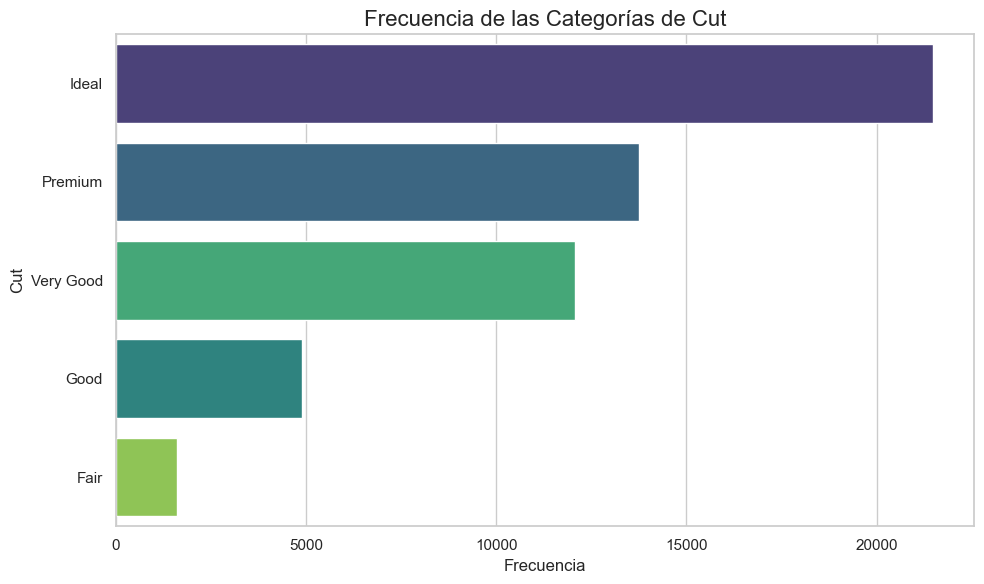

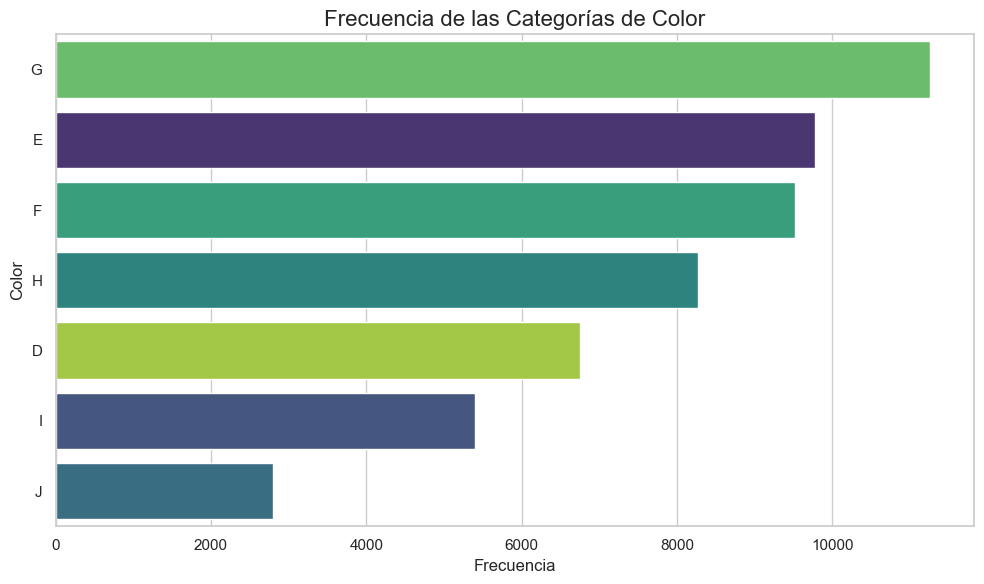

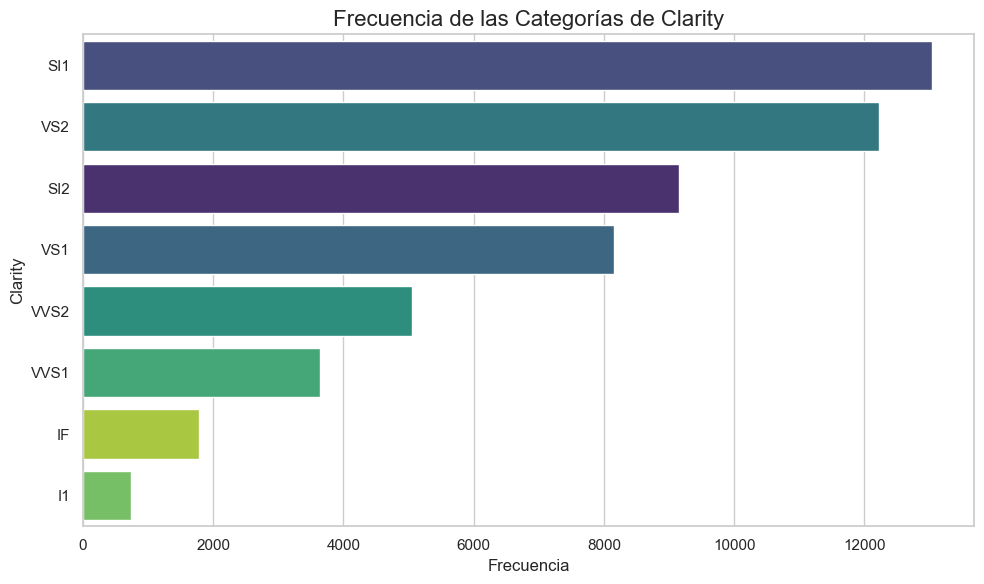

In [715]:
# Diagramas de Barras para Categóricas
for col in columnas_categoricas:
    plt.figure(figsize=(10, 6))
    # Ordenar las barras por frecuencia (descendente)
    order = diamonds_df_nuevo[col].value_counts().index
    sns.countplot(y=col, data=diamonds_df_nuevo, order=order, palette='viridis', hue=col, legend=False)
    plt.title(f'Frecuencia de las Categorías de {col.capitalize()}', fontsize=16)
    plt.xlabel('Frecuencia')
    plt.ylabel(col.capitalize())
    plt.tight_layout()
    plt.show()
    plt.close()

3. Explora relaciones bivariadas en el conjunto de datos mediante gráficos:
* Boxplots que muestren la distribución del precio para cada categoría de color, asegurándose de que las categorías se muestren en el orden de calidad de diamante de mejor a peor: D, E, F, G, H, I, J.
* ¿La tendencia de los precios se comporta como esperabas? Identifica si alguna otra variable podría estar influyendo en la tendencia observada por color y comenta tus observaciones.
* Gráfico de dispersión del precio frente al peso de los diamantes, coloreando los puntos según la categoría de calidad del corte.
* ¿Qué relación se observa entre el peso del diamante y su precio según la calidad del corte?

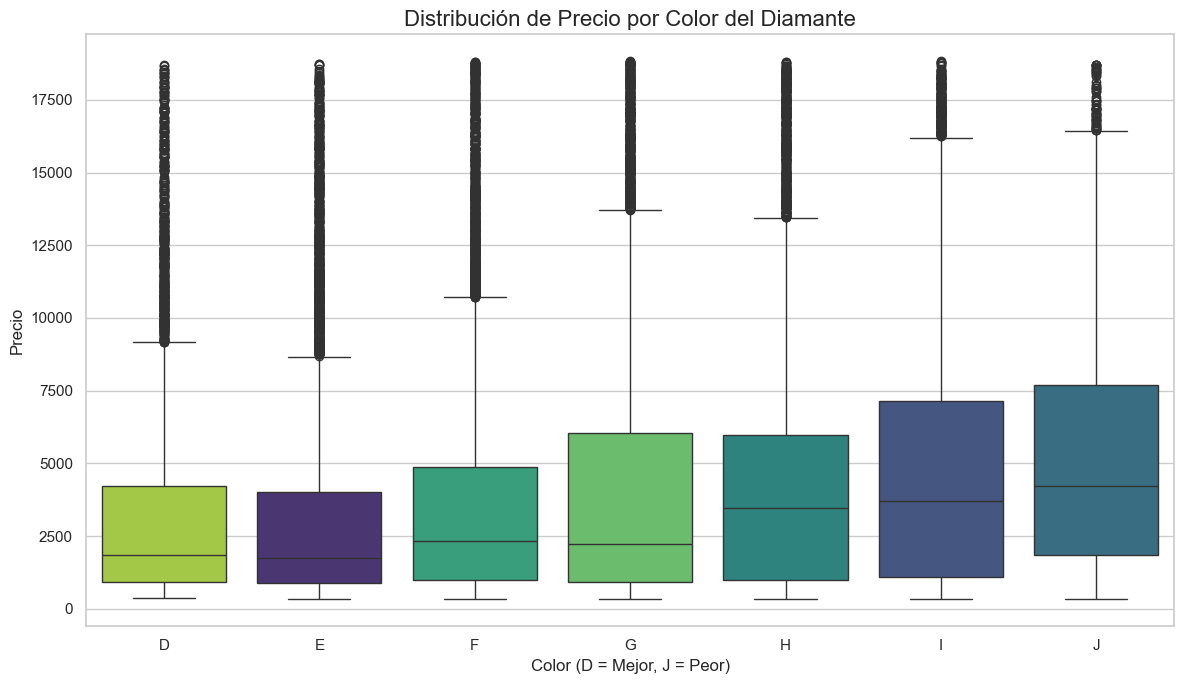

In [716]:
# Boxplots que muestren la distribución del precio para cada categoría de color, 
# asegurándose de que las categorías se muestren en el orden de calidad de diamante de mejor a peor: D, E, F, G, H, I, J.

# Definir el orden de las categorías de color (de mejor a peor calidad)
orden_color = ['D', 'E', 'F', 'G', 'H', 'I', 'J']

# Configuración de gráfico
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

sns.boxplot(x='color', y='price', data=diamonds_df_nuevo, order=orden_color, palette='viridis', hue='color', legend=False)

# Aplicar escala logarítmica al eje Y (precio) para mejorar la interpretación de la dispersión en variables 
# con un rango muy amplio y una distribución muy sesgada.
# plt.yscale('log')

# Configurar títulos y etiquetas
plt.title('Distribución de Precio por Color del Diamante', fontsize=16)
plt.xlabel('Color (D = Mejor, J = Peor)', fontsize=12)
plt.ylabel('Precio', fontsize=12)

# 6. Guardar el gráfico
plt.tight_layout()
plt.show()
plt.close()



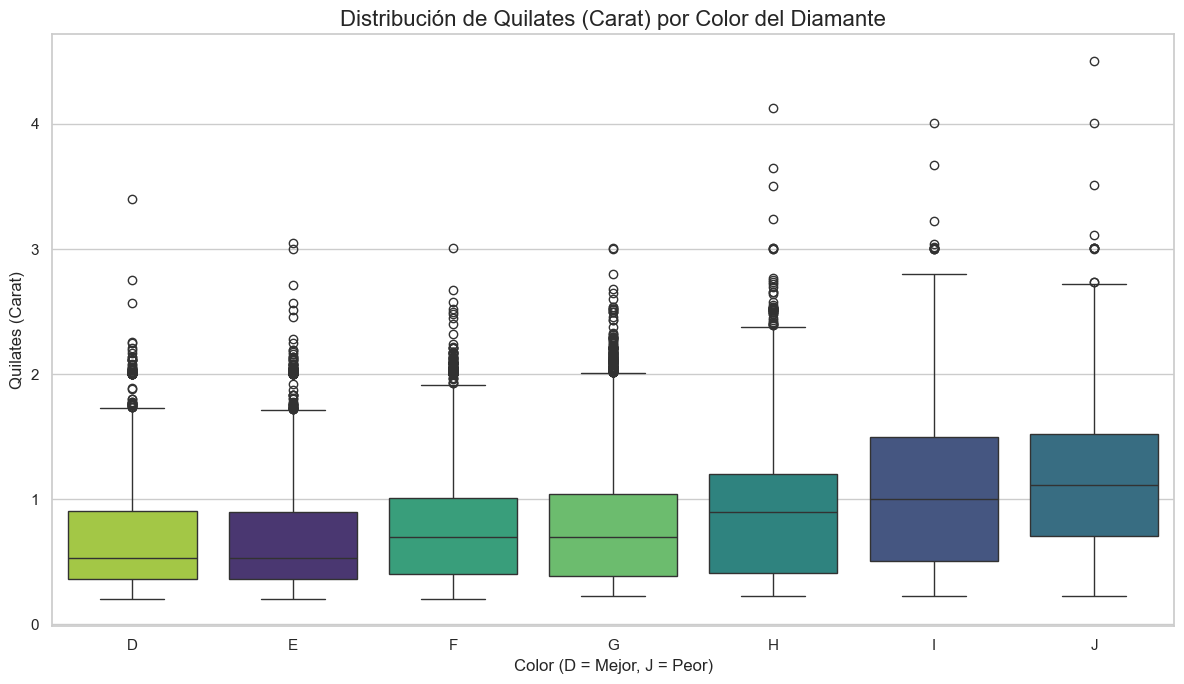

In [717]:
# ¿La tendencia de los precios se comporta como esperabas? 
# Identifica si alguna otra variable podría estar influyendo en la tendencia observada por color y comenta tus observaciones.

# Configurar el gráfico
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# Generar el Boxplot para Carat vs Color
sns.boxplot(x='color', y='carat', data=diamonds_df_nuevo, order=orden_color, hue='color', palette='viridis')

# Configurar títulos y etiquetas
plt.title('Distribución de Quilates (Carat) por Color del Diamante', fontsize=16)
plt.xlabel('Color (D = Mejor, J = Peor)', fontsize=12)
plt.ylabel('Quilates (Carat)', fontsize=12)

plt.tight_layout()
plt.show()
plt.close()

Text(0, 0.5, 'Precio')

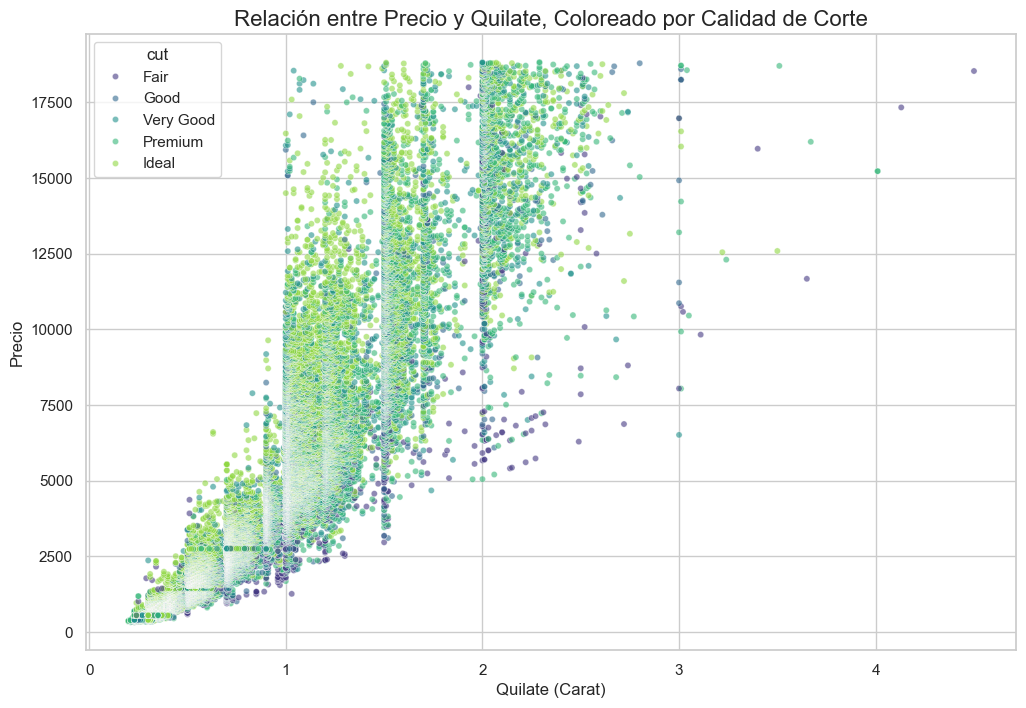

In [718]:
# Gráfico de dispersión del precio frente al peso de los diamantes, coloreando los puntos según la categoría de calidad del corte.

# Definir el orden de calidad del corte (de peor a mejor)
orden_corte = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']

# Configurar el gráfico
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

# 3. Generar el Gráfico de Dispersión
# Se aplica escala logarítmica a ambos ejes ('carat' y 'price') para visualizar la relación exponencial.
sns.scatterplot(
    x='carat',
    y='price',
    hue='cut',
    data=diamonds_df_nuevo,
    s=20, # Tamaño de los puntos
    alpha=0.6, # Transparencia para manejar el solapamiento de puntos
    palette='viridis',
    hue_order=orden_corte # Aplicar el orden
)

# 4. Aplicar escala logarítmica a ambos ejes
#plt.xscale('log')
#plt.yscale('log')

# 5. Configurar títulos y etiquetas
plt.title('Relación entre Precio y Quilate, Coloreado por Calidad de Corte', fontsize=16)
plt.xlabel('Quilate (Carat)', fontsize=12)
plt.ylabel('Precio', fontsize=12)

4. Dibuja un mapa de calor con la matriz de correlación para las variables numéricas del conjunto de datos.
* Identifica los pares de variables cuya correlación sea superior a 0.9 e imprímelos.
* Analiza la correlación entre los predictores (excluyendo `price`), identifica si un único predictor captura información que también está presente en varios otros y elimina los predictores redundantes para simplificar la complejidad de los modelos que construirás más adelante.
* Vuelve a generar el mapa de calor para verificar que ya no queden predictores altamente correlacionados.

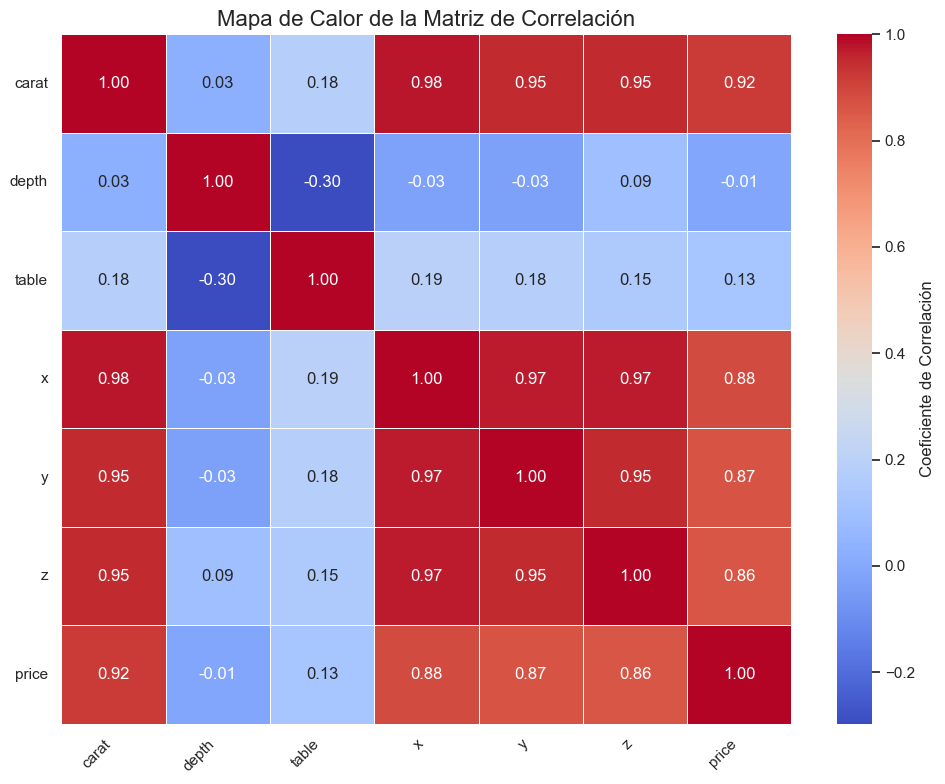

Pares de variables con correlación positiva superior a 0.9:
| Variable 1   | Variable 2   | Correlación   |
|:-------------|:-------------|:--------------|
| carat        | x            | 0.975627      |
| x            | y            | 0.974569      |
| x            | z            | 0.97066       |
| carat        | z            | 0.953711      |
| carat        | y            | 0.952146      |
| y            | z            | 0.951804      |
| carat        | price        | 0.921845      |


In [719]:
# Dibuja un mapa de calor con la matriz de correlación para las variables numéricas del conjunto de datos.
# Calcular la matriz de correlación
matriz_correlacion = diamonds_df_nuevo[columnas_numericas].corr()

# Configurar el tamaño del gráfico
plt.figure(figsize=(10, 8))

# Generar el Mapa de Calor (Heatmap)
sns.heatmap(
    matriz_correlacion,
    annot=True, # Mostrar los valores de correlación
    cmap='coolwarm', # Esquema de color
    fmt='.2f', # Dos decimales en las anotaciones
    linewidths=.5,
    cbar_kws={'label': 'Coeficiente de Correlación'}
)

# Configurar títulos
plt.title('Mapa de Calor de la Matriz de Correlación', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# Mostrar el gráfico
plt.tight_layout()
plt.show()
plt.close()

# Imprimir pares de variables cuya correlación sea superior a 0.9
# stack() transforma la matriz simétrica en una Serie de pares (Variable 1, Variable 2)
pares_correlacion = matriz_correlacion.stack().reset_index()
pares_correlacion.columns = ['Variable 1', 'Variable 2', 'Correlación']

high_correlations = pares_correlacion[
    (pares_correlacion['Correlación'] > 0.9) &  
    (pares_correlacion['Variable 1'] != pares_correlacion['Variable 2']) & 
    (pares_correlacion['Variable 1'] < pares_correlacion['Variable 2']) 
]

# 4. Ordenar por correlación descendente
high_correlations = high_correlations.sort_values(by='Correlación', ascending=False).reset_index(drop=True)

# Imprimir el resultado
print("Pares de variables con correlación positiva superior a 0.9:")
print(high_correlations.to_markdown(index=False, numalign='left', stralign='left'))

In [720]:
# Predictores identificados como redundantes y eliminados
predictores_redundantes = ['x', 'y', 'z']
print(f"Predictores identificados como redundantes y que serán eliminados: {predictores_redundantes}")

# Eliminar los predictores redundantes del DataFrame
diamonds_df_nuevo = diamonds_df_nuevo.drop(columns=predictores_redundantes)

# Mostrar las columnas restantes para confirmar la simplificación
print("\nColumnas restantes en el DataFrame simplificado:")
print(diamonds_df_nuevo.columns.tolist())

Predictores identificados como redundantes y que serán eliminados: ['x', 'y', 'z']

Columnas restantes en el DataFrame simplificado:
['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price']


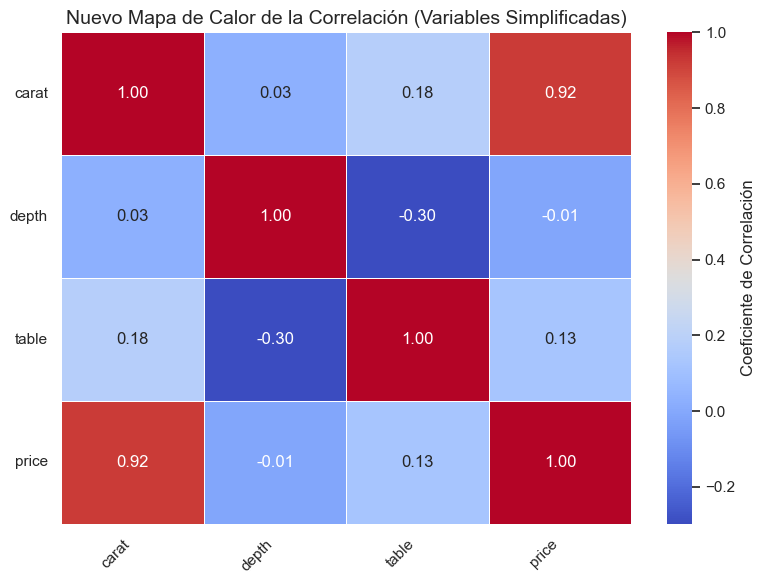

In [721]:
# Vuelve a generar el mapa de calor para verificar que ya no queden predictores altamente correlacionados.

columnas_numericas_restantes = ['carat', 'depth', 'table', 'price']
nueva_matriz_correlacion = diamonds_df_nuevo[columnas_numericas_restantes].corr()

# Configurar el tamaño del gráfico
plt.figure(figsize=(8, 6))

# Generar el nuevo Mapa de Calor
sns.heatmap(
    nueva_matriz_correlacion,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=.5,
    cbar_kws={'label': 'Coeficiente de Correlación'}
)

# 4. Configurar títulos
plt.title('Nuevo Mapa de Calor de la Correlación (Variables Simplificadas)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# 5. Mostrar nuevo mapa de calor
plt.tight_layout()
plt.show()
plt.close()


5. Construye un modelo de regresión simple utilizando únicamente la variable predictora que tenga la mayor correlación con `price`. Para ello:
* Asigna esta variable a `X` y `price` a `y` y divide el conjunto de datos en entrenamiento y prueba (80:20), usando `random_state=1` para garantizar reproducibilidad.
* Entrena un modelo con `LinearRegression()` de scikit-learn y evalúalo en el conjunto de prueba utilizando las métricas `RMSE` (Root Mean Squared Error) y `R²` (coeficiente de determinación).
* Añade los valores obtenidos a un dataframe de resultados, que incluya el nombre del modelo (*Baseline*) y una columna para cada métrica.
* Muestra la ecuación de la regresión lineal utilizando el intercepto y el coeficiente asociado al predictor. La ecuación debe tener la forma:
> `price = intercepto + coeficiente × predictor`

In [722]:
# El predictor con la correlación más alta con price (0.92) es carat. 
# Utilizaremos esta variable para construir el modelo de regresión simple.

variable_predictora = 'carat'

# Asignar X e y
# X debe ser una matriz 2D para scikit-learn.
X = diamonds_df_nuevo[[variable_predictora]]
y = diamonds_df_nuevo['price']

# Dividir el conjunto de datos en entrenamiento (80%) y prueba (20%)
# Usando random_state=1 para reproducibilidad.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)

# Mostrar la forma de los conjuntos de datos para confirmación
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")


X_train shape: (43032, 1)
X_test shape: (10758, 1)
y_train shape: (43032,)
y_test shape: (10758,)


In [723]:
# Entrena un modelo con LinearRegression() de scikit-learn y evalúalo en el conjunto de prueba utilizando las métricas 
# RMSE (Root Mean Squared Error) y R² (coeficiente de determinación).

model = LinearRegression()
model.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred = model.predict(X_test)

# RMSE
rmse = root_mean_squared_error(y_test, y_pred)

# 4. Imprimir resultados y parámetros del modelo
print("--- Evaluación del Modelo de Regresión Lineal Simple (Predictor: Carat) ---")
print(f"Intercepto (b0): {model.intercept_:.2f}")
print(f"Coeficiente (b1 - Carat): {model.coef_[0]:.2f}")
print(f"R² (Coeficiente de Determinación): {r2:.4f}")
print(f"RMSE (Root Mean Squared Error): {rmse:.2f}")


--- Evaluación del Modelo de Regresión Lineal Simple (Predictor: Carat) ---
Intercepto (b0): -2263.12
Coeficiente (b1 - Carat): 7775.23
R² (Coeficiente de Determinación): 0.9036
RMSE (Root Mean Squared Error): 1552.85


In [724]:
# Añade los valores obtenidos a un dataframe de resultados, que incluya el nombre del modelo (Baseline)
# y una columna para cada métrica.

# Metricas de evaluacion, bo y b1 son parámetros del modelo
resultado_df = pd.DataFrame({
    'Modelo': ['Baseline'],
    'R²': [r2],
    'RMSE': [rmse]
})
# Mostrar el DataFrame de resultados
print(resultado_df.to_markdown(index=False, numalign='left', stralign='left'))

| Modelo   | R²       | RMSE    |
|:---------|:---------|:--------|
| Baseline | 0.903555 | 1552.85 |


6. Utiliza todas las variables como predictoras para crear un segundo modelo:
* Haz la asignación correspondiente en `X` y `y` y divide en entrenamiento y prueba usando la misma configuración del ejercicio anterior.
* Prepara un transformador, denominado `preprocessing`, para aplicar escalamiento robusto a los predictores numéricos y codificación ordinal a los categóricos. Asegúrate de respetar el orden correcto de cada categoría, tal como se indica en la descripción de las variables.
* Construye un pipeline que combine el transformador creado con un modelo de regresión lineal.
* Añade los valores de las métricas obtenidas al dataframe de resultados, utilizando como nombre del modelo *Ordinal_Robust*.

In [725]:
# Asignación de X (Predictoras) y y (Objetivo)
X = diamonds_df_nuevo.drop('price', axis=1)
y = diamonds_df_nuevo['price']

# División en Conjuntos de Entrenamiento (80%) y Prueba (20%)
# El parámetro test_size=0.2 asigna el 20% para la prueba, dejando el 80% para el entrenamiento.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

print(f"Dimensiones de X_train (80%): {X_train.shape}")
print(f"Dimensiones de X_test (20%): {X_test.shape}")

numeric_features = diamonds_df_nuevo.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_features = diamonds_df_nuevo.select_dtypes(include=['object']).columns.tolist()

print(f"Numéricas identificadas: {numeric_features}")
print(f"Categóricas identificadas: {categorical_features}")

cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal'] 
color_order = ['J', 'I', 'H', 'G', 'F', 'E', 'D'] 
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF'] 
categories_list = [cut_order, color_order, clarity_order]

# Creación de Transformadores y ColumnTransformer ---
numeric_transformer = RobustScaler()

# Asegúrate de que el orden de las categorías en categories_list 
# corresponda al orden de las columnas en categorical_features.
categorical_transformer = OrdinalEncoder(categories=categories_list, 
                                         handle_unknown='use_encoded_value', 
                                         unknown_value=-1)

if 'price' in numeric_features:
    numeric_features.remove('price')

preprocessing = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough' 
)

print("\n✅ El transformador 'preprocessing' ha sido creado de forma dinámica.")


Dimensiones de X_train (80%): (43032, 6)
Dimensiones de X_test (20%): (10758, 6)
Numéricas identificadas: ['carat', 'depth', 'table', 'price']
Categóricas identificadas: ['cut', 'color', 'clarity']

✅ El transformador 'preprocessing' ha sido creado de forma dinámica.


In [726]:
# Construye un pipeline que combine el transformador creado con un modelo de regresión lineal.

# Definición del Modelo de Regresión Lineal
model = LinearRegression()

# Creación del Pipeline con make_pipeline
pipeline = make_pipeline(preprocessing, model)

# Entrenamiento del Pipeline
# El .fit() maneja automáticamente el ajuste y la transformación de X_train.
pipeline.fit(X_train, y_train)

print("✅ Pipeline 'Ordinal_Robust' construido y entrenado exitosamente.")

✅ Pipeline 'Ordinal_Robust' construido y entrenado exitosamente.


In [727]:
# Predicción
# Se usa el 20% de los datos de prueba (X_test) para evaluar el rendimiento.
y_pred = pipeline.predict(X_test)

# Cálculo de Métricas de Regresión
r2 = r2_score(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred) 
mae = mean_absolute_error(y_test, y_pred)

resultados_df = pd.DataFrame(columns=['Modelo', 'R2', 'RMSE', 'MAE'])

new_results = {
    'Modelo': ['Ordinal_Robust'],
    'R2': [r2],
    'RMSE': [rmse],
    'MAE': [mae]
}

# Inicializamos 'resultados_df' con estos valores directamente.
resultados_df = pd.DataFrame(new_results)

print("------------- Resultados del dataFrame -------------")
print(resultados_df)

------------- Resultados del dataFrame -------------
           Modelo        R2         RMSE         MAE
0  Ordinal_Robust  0.903555  1220.022778  849.039216


7. Prepara otro transformador, llamado `preprocessing2`, que aplique escalamiento Min-Max a los predictores numéricos y codificación one-hot a los categóricos, asegurando `drop='first'` para prevenir multicolinealidad en las variables dummies generadas.
* Construye otro pipeline utilizando este nuevo transformador y, a continuación, entrena y evalúa el modelo.
* Añade los valores de las métricas obtenidas al dataframe de resultados, utilizando como nombre del modelo *OHE_MinMax*.

In [728]:
numeric_transformer_minmax = MinMaxScaler() 
categorical_transformer_onehot = OneHotEncoder(handle_unknown='ignore', drop='first')

# Combinación con ColumnTransformer
preprocessing2 = ColumnTransformer(
    transformers=[
        ('num_minmax', numeric_transformer_minmax, numeric_features),
        ('cat_onehot', categorical_transformer_onehot, categorical_features)
    ],
    remainder='passthrough'
)

print("\n✅ Transformador 'preprocessing2' creado de forma dinámica (Min-Max y One-Hot).")

# Definición del Modelo
model_lr = LinearRegression()

# Se utiliza el nuevo transformador 'preprocessing2'
pipeline_onehot = make_pipeline(preprocessing2, model_lr)

pipeline_onehot.fit(X_train, y_train)

print("✅ Pipeline 'OneHot_MinMax' construido y entrenado con éxito.")

# Predicción
y_pred_onehot = pipeline_onehot.predict(X_test)

# Cálculo de Métricas de Regresión
r2_onehot = r2_score(y_test, y_pred_onehot)
rmse_onehot = root_mean_squared_error(y_test, y_pred_onehot) 
mae_onehot = mean_absolute_error(y_test, y_pred_onehot)

# Preparación de los Resultados
new_results_onehot = {
    'Modelo': ['OneHot_MinMax'],
    'R2': [r2_onehot],
    'RMSE': [rmse_onehot],
    'MAE': [mae_onehot]
}

resultados_df = pd.concat([resultados_df, pd.DataFrame(new_results_onehot)], ignore_index=True)
    
print("\n✅ El modelo 'OneHot_MinMax' ha sido evaluado y sus métricas añadidas.")
print("\n---------- Resultados Actualizados ----------")
print(resultados_df)

print("\nEl modelo que utiliza la estrategia OneHot_MinMax tiene el mejor rendimiento")


✅ Transformador 'preprocessing2' creado de forma dinámica (Min-Max y One-Hot).
✅ Pipeline 'OneHot_MinMax' construido y entrenado con éxito.

✅ El modelo 'OneHot_MinMax' ha sido evaluado y sus métricas añadidas.

---------- Resultados Actualizados ----------
           Modelo        R2         RMSE         MAE
0  Ordinal_Robust  0.903555  1220.022778  849.039216
1   OneHot_MinMax  0.915967  1138.813375  795.119702

El modelo que utiliza la estrategia OneHot_MinMax tiene el mejor rendimiento


8. Modifica el pipeline anterior para emplear regresión polinomial de segundo grado y evalúa si esto mejora el ajuste del modelo.
* Añade los valores de las métricas obtenidas al dataframe de resultados, utilizando como nombre del modelo *PolynomialDegree2*.

In [729]:
# Definición del Generador Polinomial
# degree=2 crea términos cuadrados y de interacción (X1^2, X2^2, X1*X2)
poly_features = PolynomialFeatures(degree=2, include_bias=False)

# Creación del Pipeline Polinomial
# make_pipeline(preprocessing2) -> aplica OHE y MinMax
# -> (poly_features) -> genera características cuadráticas/interacción
# -> (LinearRegression) -> entrena el modelo final
pipeline_poly = make_pipeline(preprocessing2, poly_features, LinearRegression())

# Entrenamiento del Pipeline
# El .fit() aplica TODOS los pasos a X_train.
pipeline_poly.fit(X_train, y_train)

print("✅ Pipeline Polinomial de Grado 2 construido y entrenado con éxito.")


# Predicción
y_pred_poly = pipeline_poly.predict(X_test)

# Cálculo de Métricas de Regresión
r2_poly = r2_score(y_test, y_pred_poly)
rmse_poly = root_mean_squared_error(y_test, y_pred_poly) 
mae_poly = mean_absolute_error(y_test, y_pred_poly)

# 3. Preparación de los Resultados usando el nombre solicitado
new_results_poly = {
    'Modelo': ['PolynomialDegree2'],
    'R2': [r2_poly],
    'RMSE': [rmse_poly],
    'MAE': [mae_poly]
}

# 4. Adición al DataFrame de Resultados
new_df = pd.DataFrame(new_results_poly)
resultados_df = pd.concat([resultados_df, new_df], ignore_index=True)
    
print("\n✅ El modelo 'PolynomialDegree2' ha sido evaluado y sus métricas añadidas.")
print("\n--- Resultados Actualizados ---")
print(resultados_df)

✅ Pipeline Polinomial de Grado 2 construido y entrenado con éxito.

✅ El modelo 'PolynomialDegree2' ha sido evaluado y sus métricas añadidas.

--- Resultados Actualizados ---
              Modelo        R2         RMSE         MAE
0     Ordinal_Robust  0.903555  1220.022778  849.039216
1      OneHot_MinMax  0.915967  1138.813375  795.119702
2  PolynomialDegree2  0.964798   737.080112  472.965048


9. Ordena el dataframe de resultados según el `R²`, de manera que el modelo con mejor desempeño aparezca primero.
* Para dicho modelo, crea un gráfico de dispersión de los valores reales frente a los predichos, e incluye una línea diagonal de referencia para indicar una predicción perfecta.

--- DataFrame de Resultados Ordenado por R2 (Mejor Modelo Primero) ---
              Modelo        R2         RMSE         MAE
0  PolynomialDegree2  0.964798   737.080112  472.965048
1      OneHot_MinMax  0.915967  1138.813375  795.119702
2     Ordinal_Robust  0.903555  1220.022778  849.039216


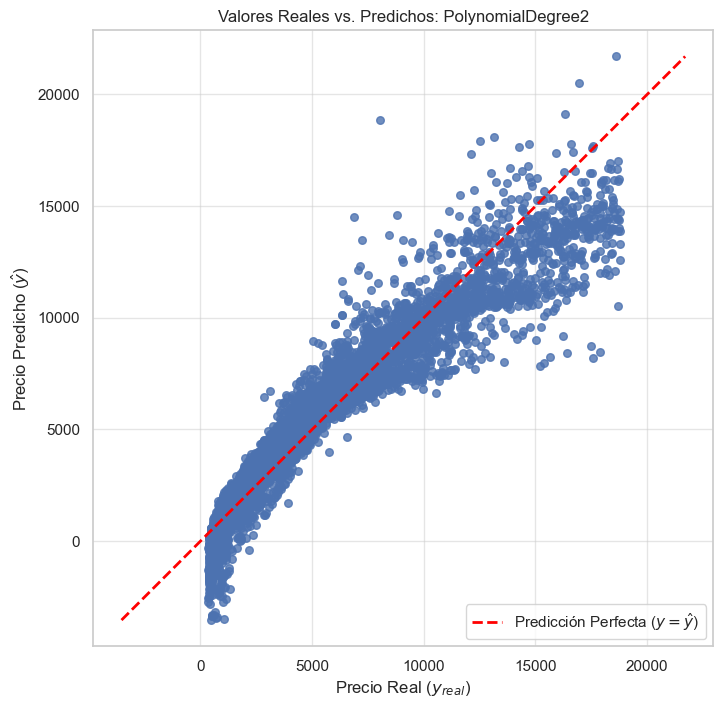

In [730]:
# --- (Predicción para el mejor modelo) ---
y_pred_best = pipeline_best.predict(X_test)

resultados_df_sorted = resultados_df.sort_values(by='R2', ascending=False).reset_index(drop=True)
print("--- DataFrame de Resultados Ordenado por R2 (Mejor Modelo Primero) ---")
print(resultados_df_sorted)

# Identificar el mejor modelo para el título del gráfico
best_model_name = resultados_df_sorted.iloc[0]['Modelo']

# Se entrena el modelo OneHot_MinMax (el mejor)
pipeline_best = make_pipeline(preprocessing2, LinearRegression())
pipeline_best.fit(X_train, y_train)

# Crear el Gráfico de Dispersión
plt.figure(figsize=(8, 8))
# Gráfico de dispersión de valores reales vs. predichos
plt.scatter(y_test, y_pred_best, alpha=0.8, s=30) 

# Línea de referencia (y=x) para la predicción perfecta
min_val = min(y_test.min(), y_pred_best.min())
max_val = max(y_test.max(), y_pred_best.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Predicción Perfecta ($y=\hat{y}$)')

# Etiquetas y título
plt.title(f'Valores Reales vs. Predichos: {best_model_name}')
plt.xlabel('Precio Real ($y_{real}$)')
plt.ylabel('Precio Predicho ($\hat{y}$)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.5)
plt.axis('equal') 

plt.show()

10. Muestra la representación gráfica del pipeline para ubicar la posición de cada elemento dentro del flujo del modelo.
* Obtén los nombres de todas las columnas después del preprocesamiento (numéricas y dummies de categóricas).
* Extrae los nombres de las columnas polinómicas.
* Recupera los coeficientes y el intercepto del modelo de regresión lineal.
* Ordena los coeficientes por su valor absoluto para mostrar los 10 más importantes y da conclusiones sobre cómo los distintos factores influyen en el precio.

In [731]:
# Obtén los nombres de todas las columnas después del preprocesamiento (numéricas y dummies de categóricas).
# Acceder al transformador OHE dentro del ColumnTransformer
ohe_transformer = pipeline_poly['columntransformer'].named_transformers_['cat_onehot']

# Obtener los nombres de las nuevas columnas dummy (One-Hot)
# 'input_features' es la lista de columnas originales que entraron al OHE
ohe_feature_names = ohe_transformer.get_feature_names_out(categorical_features)

# Obtener los nombres de las columnas numéricas (que no fueron eliminadas ni transformadas en OHE)
num_feature_names = numeric_features 
# NOTA: Los nombres numéricos siguen siendo los mismos: ['carat', 'depth', 'table']

# Concatenar todos los nombres de columnas después del preprocesamiento
all_preprocessed_features = np.concatenate([num_feature_names, ohe_feature_names])

print(f"Número de características después del preprocesamiento: {len(all_preprocessed_features)}")
print(f"Ejemplo de características: {all_preprocessed_features[:5]}")

Número de características después del preprocesamiento: 20
Ejemplo de características: ['carat' 'depth' 'table' 'cut_Good' 'cut_Ideal']


In [732]:
# Extrae los nombres de las columnas polinómicas.
# Acceder al transformador polinomial
poly_transformer = pipeline_poly['polynomialfeatures']

# Obtener los nombres de las características después de la expansión polinomial
final_feature_names = poly_transformer.get_feature_names_out(all_preprocessed_features)

print(final_feature_names)
print(f"Número total de características después de la expansión polinomial: {len(final_feature_names)}")
print(f"Ejemplo de características polinomiales: {final_feature_names[-5:]}")

['carat' 'depth' 'table' 'cut_Good' 'cut_Ideal' 'cut_Premium'
 'cut_Very Good' 'color_E' 'color_F' 'color_G' 'color_H' 'color_I'
 'color_J' 'clarity_IF' 'clarity_SI1' 'clarity_SI2' 'clarity_VS1'
 'clarity_VS2' 'clarity_VVS1' 'clarity_VVS2' 'carat^2' 'carat depth'
 'carat table' 'carat cut_Good' 'carat cut_Ideal' 'carat cut_Premium'
 'carat cut_Very Good' 'carat color_E' 'carat color_F' 'carat color_G'
 'carat color_H' 'carat color_I' 'carat color_J' 'carat clarity_IF'
 'carat clarity_SI1' 'carat clarity_SI2' 'carat clarity_VS1'
 'carat clarity_VS2' 'carat clarity_VVS1' 'carat clarity_VVS2' 'depth^2'
 'depth table' 'depth cut_Good' 'depth cut_Ideal' 'depth cut_Premium'
 'depth cut_Very Good' 'depth color_E' 'depth color_F' 'depth color_G'
 'depth color_H' 'depth color_I' 'depth color_J' 'depth clarity_IF'
 'depth clarity_SI1' 'depth clarity_SI2' 'depth clarity_VS1'
 'depth clarity_VS2' 'depth clarity_VVS1' 'depth clarity_VVS2' 'table^2'
 'table cut_Good' 'table cut_Ideal' 'table cut_Pre

In [733]:
# Recupera los coeficientes y el intercepto del modelo de regresión lineal.
# Acceder al modelo de regresión lineal
linear_model = pipeline_poly['linearregression']

# Intercepto (Beta 0)
intercept = linear_model.intercept_

# Coeficientes (Betas 1, 2, 3, ...)
coefficients = linear_model.coef_

print(f"\nIntercepto del modelo: {intercept:.2f}")


Intercepto del modelo: -2690.42


In [734]:
# Ordena los coeficientes por su valor absoluto para mostrar los 10 más importantes y da conclusiones sobre cómo los distintos factores 
# influyen en el precio.

# Crear un DataFrame para asociar coeficientes con sus nombres
coef_df = pd.DataFrame({
    'Caracteristica': final_feature_names,
    'Coeficiente': coefficients
})

# Calcular el valor absoluto para medir la importancia
coef_df['Importancia_Absoluta'] = np.abs(coef_df['Coeficiente'])

# Ordenar por importancia absoluta y obtener el top 10
top_10_coefs = coef_df.sort_values(by='Importancia_Absoluta', ascending=False).head(10).reset_index(drop=True)

print("\n--- Top 10 Coeficientes Polinomiales más Importantes (Ordenados por Impacto) ---")
print(top_10_coefs[['Caracteristica', 'Coeficiente']])




--- Top 10 Coeficientes Polinomiales más Importantes (Ordenados por Impacto) ---
       Caracteristica   Coeficiente
0             carat^2  54163.732984
1    carat clarity_IF  51513.938078
2  carat clarity_VVS1  48359.690382
3  carat clarity_VVS2  46101.345192
4   carat clarity_VS1  41363.403111
5   carat clarity_VS2  38503.629001
6   carat clarity_SI1  33403.226623
7   carat clarity_SI2  25822.889781
8       carat color_J -20575.104283
9       carat color_I -14077.703142
